In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("/mnt/c/Users/PAVILION/Desktop/Cyberslacking-hackathon-Aug-01-2026/Reid Library/reid_library_sensor_data.csv")
df

,Unnamed: 0,timestamp,power_kw,airflow_m3s,water_pressure_kpa,water_flow_lps,temperature_c,vibration_level,sound_event,system_status,sensor_source
0,0,2026-07-01 00:00:00,49.391,4.674,361.114,2.310,19.389,0.130,normal,stable,original
1,1,2026-07-01 01:00:00,47.613,4.452,372.913,2.239,18.724,0.146,normal,stable,original
2,2,2026-07-01 02:00:00,49.814,4.727,333.217,2.109,18.591,0.126,normal,stable,original
3,3,2026-07-01 03:00:00,52.264,5.033,356.756,2.003,18.998,0.141,normal,stable,original
4,4,2026-07-01 04:00:00,47.344,4.418,342.192,2.205,18.915,0.093,normal,stable,original
...,...,...,...,...,...,...,...,...,...,...,...
495,495,2026-07-21 15:00:00,49.509,4.839,356.627,2.451,19.535,0.174,normal,stable,barry_j_
496,496,2026-07-21 16:00:00,45.096,4.287,381.572,2.459,18.987,0.142,normal,stable,barry_j_
497,497,2026-07-21 17:00:00,47.467,4.583,367.690,2.331,18.559,0.142,normal,stable,barry_j_
498,498,2026-07-21 18:00:00,45.548,4.344,353.146,2.304,18.918,0.174,normal,stable,barry_j_


In [39]:
missing = df.isnull().sum().reset_index()
missing.columns = ["column_name", "missing_values"]
print(missing.to_string(index=False))

       column_name  missing_values
        Unnamed: 0               0
         timestamp               0
          power_kw               0
       airflow_m3s               2
water_pressure_kpa               2
    water_flow_lps               1
     temperature_c               0
   vibration_level               1
       sound_event               0
     system_status               0
     sensor_source               0


In [40]:
numeric_cols = df.select_dtypes(include="number").columns

summary = pd.DataFrame({
    "column_name": numeric_cols,
    "mean": [df[c].mean() for c in numeric_cols],
    "median": [df[c].median() for c in numeric_cols],
    "st_dev": [df[c].std() for c in numeric_cols],
    "min": [df[c].min() for c in numeric_cols],
    "max": [df[c].max() for c in numeric_cols],
    "iqr_range": [df[c].quantile(0.75) - df[c].quantile(0.25) for c in numeric_cols],
})

summary = summary.round(3)
print(summary.to_string(index=False))

       column_name    mean  median  st_dev    min     max  iqr_range
        Unnamed: 0 249.500 249.500 144.482  0.000 499.000    249.500
          power_kw  47.251  47.838   4.353 27.658  58.788      4.014
       airflow_m3s   4.300   4.424   0.632  1.957   5.848      0.593
water_pressure_kpa 326.981 348.852  70.530 58.806 381.611     19.894
    water_flow_lps   1.969   2.093   0.486  0.094   2.540      0.251
     temperature_c  18.825  18.978   0.982 14.126  20.597      0.677
   vibration_level   0.247   0.164   0.214  0.059   1.131      0.109


In [41]:
cafe = pd.read_csv("/mnt/c/Users/PAVILION/Desktop/Cyberslacking-hackathon-Aug-01-2026/ds sidequest/dirty_cafe_sales.csv")
cafe

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [42]:
# Forward fill missing values in the Location column
cafe["Location"] = cafe["Location"].ffill()

# Calculate frequency of each categorical value
freq = cafe["Location"].value_counts().reset_index()
freq.columns = ["location", "frequency"]

print(freq.to_string(index=False))

location  frequency
In-store       4497
Takeaway       4494
   ERROR        506
 UNKNOWN        503


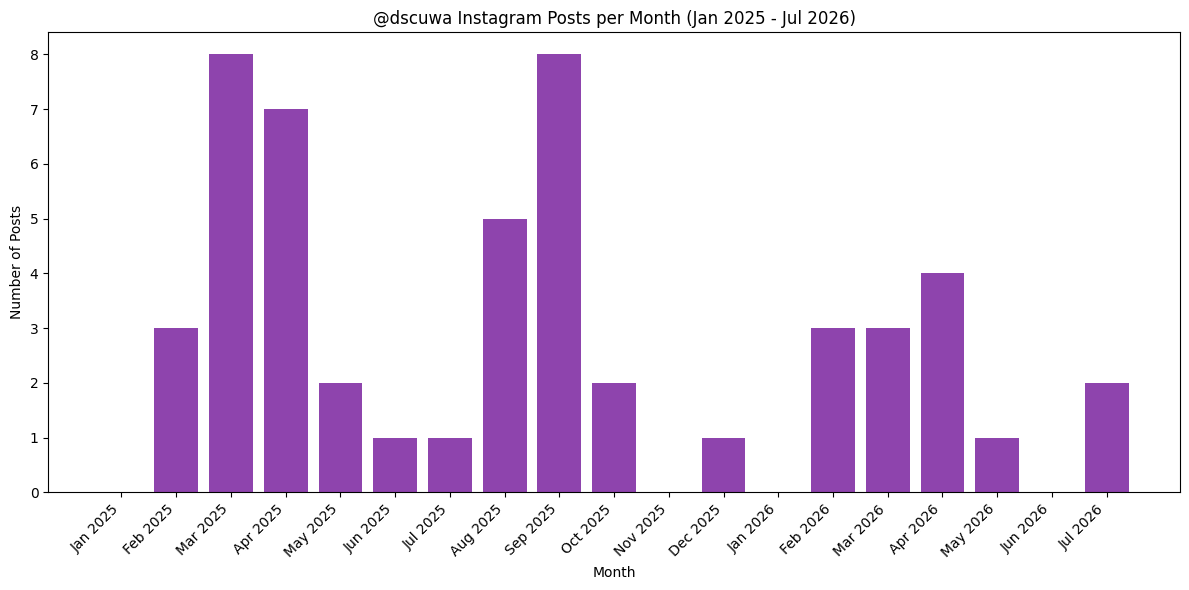

In [44]:
frequency = [0, 3, 8, 7, 2, 1, 1, 5, 8, 2, 0, 1, 0, 3, 3, 4, 1, 0, 2]

# 19 months: Jan 2025 through Jul 2026
months = pd.date_range(start="2025-01-01", end="2026-07-01", freq="MS").strftime("%b %Y")

plt.figure(figsize=(12, 6))
plt.bar(months, frequency, color="#8e44ad")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.title("@dscuwa Instagram Posts per Month (Jan 2025 - Jul 2026)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("dscuwa_posts_chart.png", dpi=150)
plt.show()

in your presentation later please explain the methods we used to implement the data and visualize the visualisations.